# 🏥 Healthcare Risk Adjustment Analytics

## Suspect Member Prioritization + Provider Action Planning

This notebook is the full technical story behind the Streamlit healthcare risk command center.

The goal is to show how a healthcare data scientist can move from a business problem to a model-driven operational workflow.

### What this notebook teaches

- how to simulate a HIPAA-safe payer dataset
- how to explore healthcare risk patterns
- how to train and compare predictive models
- how to evaluate a ranked review queue
- how to translate model output into provider and plan-level action
- how to explain the project clearly in a data science interview

> Dataset note: all data is synthetic. No real PHI, patient data, claims data, or proprietary payer data is used.


## 🧭 Notebook Roadmap

Think of this notebook as a healthcare analytics case study.

| Phase | What happens | Why it matters |
|---|---|---|
| 1 | Set up the project | Make the notebook reproducible |
| 2 | Generate synthetic healthcare data | Create a safe member-level dataset |
| 3 | Run data quality checks | Validate the data before modeling |
| 4 | Explore risk patterns | Understand RAF, claims, care gaps, and provider variation |
| 5 | Train ML models | Predict members likely to need documentation review |
| 6 | Build priority tiers | Convert probabilities into an operational worklist |
| 7 | Validate statistically | Add analyst-level reasoning and controls |
| 8 | Model plan transfer | Connect analytics to healthcare finance |
| 9 | Interview guide | Explain the project confidently |


## 1️⃣ Project Setup

### What this code does

This first code cell imports the Python libraries and reusable project functions.

The reusable logic lives in `src/risk_adjustment_pipeline.py`, which keeps this notebook clean and interview-friendly.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_adjustment_pipeline import (
    MODEL_FEATURES,
    TARGET,
    classification_summary,
    feature_importance,
    generate_synthetic_members,
    plan_transfer_table,
    provider_action_table,
    score_members,
    summarize_priority_queue,
    train_models,
)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
for folder in [DATA_DIR, OUTPUT_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print("Setup complete.")


Project root: /Users/birjungthapa/Documents/HealthCare_projects
Setup complete.


## 2️⃣ Generate Synthetic Healthcare Member Data

### Business intuition

A payer risk adjustment dataset usually contains member demographics, plan information, utilization, clinical burden, care gaps, and risk scores.

Because real healthcare data contains PHI, this project creates a synthetic dataset that behaves like healthcare data without exposing real people.

### Interview checkpoint

If asked why synthetic data was used:

> I used synthetic data because healthcare data is sensitive. The project focuses on workflow design, modeling logic, and business interpretation without using PHI.


In [2]:
df = generate_synthetic_members(n_members=5000, seed=42)
raw_data_path = DATA_DIR / "synthetic_healthcare_risk_members.csv"
df.to_csv(raw_data_path, index=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Synthetic suspect rate: {df[TARGET].mean():.1%}")
display(df.head(10))


Rows: 5,000
Columns: 26
Synthetic suspect rate: 17.9%


,MemberID,Region,ProviderGroup,Age,Gender,Visits,ER_Visits,Inpatient_Admits,RX_Count,Diabetes,COPD,CKD,CHF,Depression,ChronicCount,Prior_HCC_Flag,New_Diagnosis_Flag,CareGapCount,RAF_Score,PaidClaimsPMPM,SuspectFlag,PlanID,MemberMonths,AV,AgeBand,OpportunitySegment
0,100000,South,BayCare Network,77,M,6,0,0,3,1,0,0,0,0,1,0,0,1,0.970,745.720,0,PlanC_Bronze,6,0.600,75+,Monitor
1,100001,Midwest,Frontier Health,82,M,4,2,0,8,1,1,0,1,0,3,1,0,1,2.021,"1,565.390",1,PlanA_Silver,12,0.700,75+,High RAF suspect
2,100002,Northeast,Golden Valley,59,F,5,0,0,5,1,0,0,0,0,1,0,1,1,0.853,648.740,0,PlanC_Bronze,12,0.600,50-64,Monitor
3,100003,South,BayCare Network,34,F,1,0,0,2,0,0,0,0,1,1,0,0,3,0.516,486.280,0,PlanB_Gold,12,0.800,18-34,Care gap follow-up
4,100004,West,Alpha Medical Group,82,F,3,0,0,2,1,0,0,0,0,1,0,0,1,0.861,745.050,0,PlanB_Gold,12,0.800,75+,Monitor
5,100005,Northeast,Delta IPA,38,F,2,0,0,1,0,0,0,0,0,0,0,0,0,0.248,559.790,0,PlanC_Bronze,6,0.600,35-49,Monitor
6,100006,South,Golden Valley,59,F,6,0,0,4,0,0,0,0,1,1,0,1,0,0.444,614.350,1,PlanA_Silver,3,0.700,50-64,Documentation suspect
7,100007,South,Frontier Health,50,M,4,1,0,4,1,0,0,0,0,1,0,0,1,0.581,"1,085.930",0,PlanB_Gold,9,0.800,50-64,Monitor
8,100008,West,Frontier Health,47,F,3,0,0,2,0,0,0,0,1,1,1,0,1,0.820,589.380,0,PlanA_Silver,9,0.700,35-49,Monitor
9,100009,Midwest,Delta IPA,66,F,3,2,1,1,0,0,0,0,1,1,0,0,2,0.636,"1,843.390",1,PlanA_Silver,12,0.700,65-74,Documentation suspect


## 3️⃣ Data Dictionary and Quality Checks

### What we check

Before building any model, we need to understand the meaning and condition of the dataset.

This section checks:

- missing values
- data types
- unique values
- target prevalence
- healthcare feature meaning

### Why this matters

Healthcare analytics mistakes often happen before modeling. If the fields are misunderstood, the model can be technically correct but operationally useless.


In [3]:
data_dictionary = pd.DataFrame(
    [
        ("MemberID", "Synthetic member identifier; no real PHI."),
        ("Region", "Market or geography segment."),
        ("ProviderGroup", "Provider organization responsible for member care."),
        ("Age, Gender, AgeBand", "Demographic attributes for profiling and validation."),
        ("Visits, ER_Visits, Inpatient_Admits, RX_Count", "Utilization intensity signals."),
        ("Diabetes, COPD, CKD, CHF, Depression", "Synthetic chronic condition indicators."),
        ("ChronicCount", "Total count of chronic conditions."),
        ("Prior_HCC_Flag", "Whether risk was previously documented."),
        ("New_Diagnosis_Flag", "Potential new documentation opportunity."),
        ("CareGapCount", "Open care or documentation gaps."),
        ("RAF_Score", "Synthetic risk adjustment factor score."),
        ("PaidClaimsPMPM", "Synthetic paid claims per member per month."),
        ("PlanID, MemberMonths, AV", "Plan, enrollment, and actuarial value fields."),
        ("SuspectFlag", "Target: member should be prioritized for review."),
    ],
    columns=["Field", "Meaning"],
)

display(data_dictionary)

quality_summary = pd.DataFrame(
    {
        "MissingValues": df.isna().sum(),
        "UniqueValues": df.nunique(),
        "DataType": df.dtypes.astype(str),
    }
).sort_values(["MissingValues", "UniqueValues"], ascending=[False, True])

display(quality_summary)

target_summary = df[TARGET].value_counts(normalize=True).rename("Share").to_frame()
display(target_summary)


,Field,Meaning
0,MemberID,Synthetic member identifier; no real PHI.
1,Region,Market or geography segment.
2,ProviderGroup,Provider organization responsible for member c...
3,"Age, Gender, AgeBand",Demographic attributes for profiling and valid...
4,"Visits, ER_Visits, Inpatient_Admits, RX_Count",Utilization intensity signals.
5,"Diabetes, COPD, CKD, CHF, Depression",Synthetic chronic condition indicators.
6,ChronicCount,Total count of chronic conditions.
7,Prior_HCC_Flag,Whether risk was previously documented.
8,New_Diagnosis_Flag,Potential new documentation opportunity.
9,CareGapCount,Open care or documentation gaps.


,MissingValues,UniqueValues,DataType
Gender,0,2,object
Diabetes,0,2,int64
COPD,0,2,int64
CKD,0,2,int64
CHF,0,2,int64
Depression,0,2,int64
Prior_HCC_Flag,0,2,int64
New_Diagnosis_Flag,0,2,int64
SuspectFlag,0,2,int64
PlanID,0,3,object


,Share
SuspectFlag,
0,0.821
1,0.179


## 4️⃣ Exploratory Healthcare Risk Analysis

### Questions we want to answer

- What does the RAF distribution look like?
- Do suspect members have higher claims PMPM?
- Does chronic burden increase suspect probability?
- Which provider groups have higher suspect rates?

### Interview checkpoint

EDA is not just for charts. In this project, EDA validates whether the synthetic data behaves like a believable healthcare workflow.


In [4]:
kpi_summary = pd.DataFrame(
    {
        "Metric": [
            "Members",
            "Suspect rate",
            "Average RAF score",
            "Average claims PMPM",
            "Average chronic count",
            "Members with 3+ care gaps",
        ],
        "Value": [
            f"{len(df):,}",
            f"{df[TARGET].mean():.1%}",
            f"{df['RAF_Score'].mean():.3f}",
            f"${df['PaidClaimsPMPM'].mean():,.0f}",
            f"{df['ChronicCount'].mean():.2f}",
            f"{(df['CareGapCount'] >= 3).mean():.1%}",
        ],
    }
)

display(kpi_summary)

segment_summary = (
    df.groupby("OpportunitySegment")
    .agg(
        Members=("MemberID", "count"),
        SuspectRate=(TARGET, "mean"),
        AvgRAF=("RAF_Score", "mean"),
        AvgClaimsPMPM=("PaidClaimsPMPM", "mean"),
        AvgCareGaps=("CareGapCount", "mean"),
    )
    .sort_values("SuspectRate", ascending=False)
)

display(segment_summary)


,Metric,Value
0,Members,"5,000"
1,Suspect rate,17.9%
2,Average RAF score,0.652
3,Average claims PMPM,$832
4,Average chronic count,0.62
5,Members with 3+ care gaps,2.7%


,Members,SuspectRate,AvgRAF,AvgClaimsPMPM,AvgCareGaps
OpportunitySegment,,,,,
Documentation suspect,493,1.000,0.528,924.982,0.870
High RAF suspect,403,1.000,1.338,"1,456.557",1.206
Care gap follow-up,57,0.000,0.942,"1,043.441",3.193
Monitor,4047,0.000,0.595,755.772,0.479


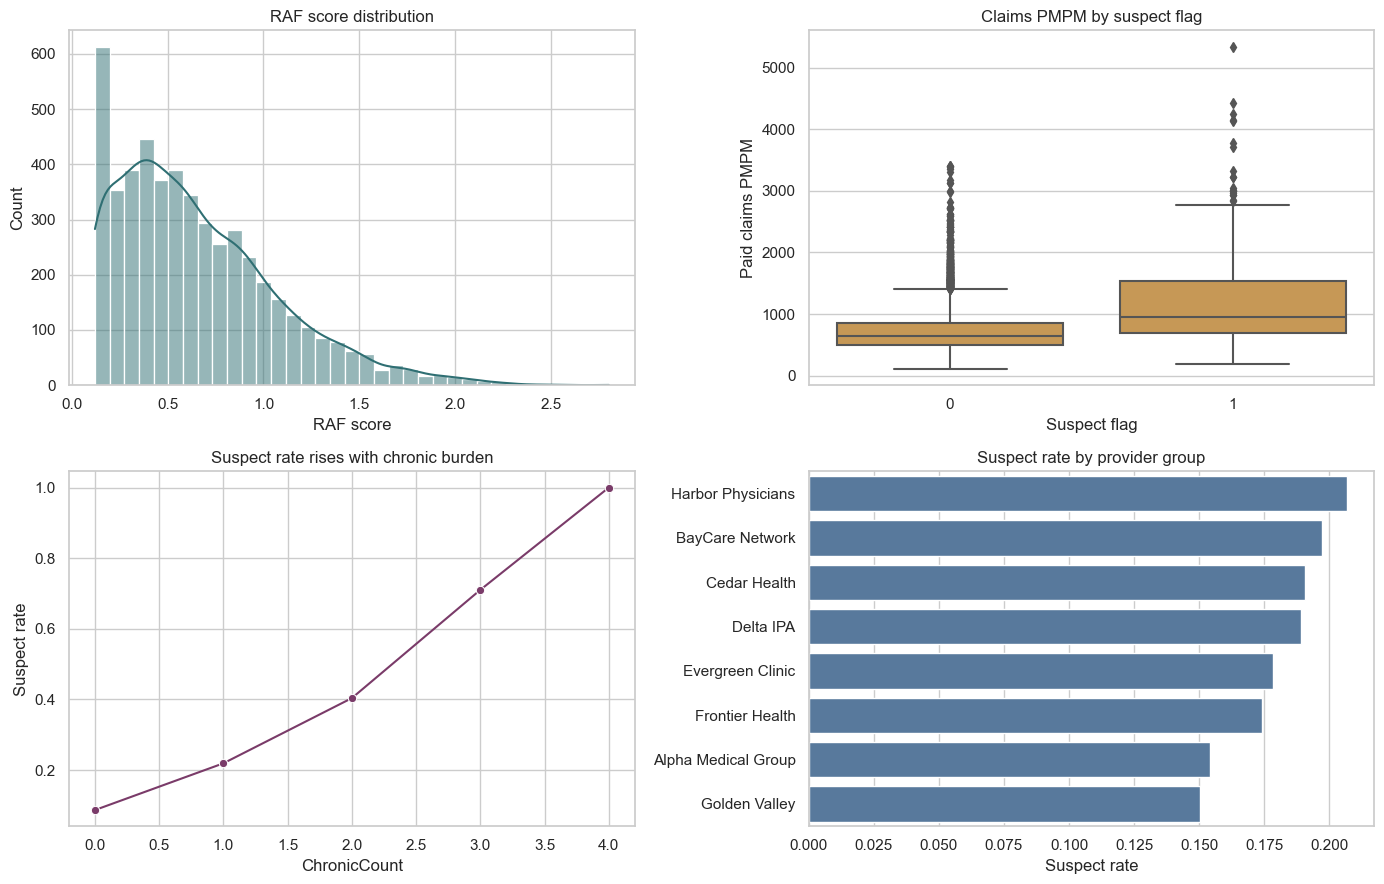

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["RAF_Score"], bins=35, kde=True, ax=axes[0, 0], color="#2f6f73")
axes[0, 0].set_title("RAF score distribution")
axes[0, 0].set_xlabel("RAF score")

sns.boxplot(data=df, x=TARGET, y="PaidClaimsPMPM", ax=axes[0, 1], color="#d99b43")
axes[0, 1].set_title("Claims PMPM by suspect flag")
axes[0, 1].set_xlabel("Suspect flag")
axes[0, 1].set_ylabel("Paid claims PMPM")

chronic_rate = df.groupby("ChronicCount")[TARGET].mean().reset_index()
sns.lineplot(data=chronic_rate, x="ChronicCount", y=TARGET, marker="o", ax=axes[1, 0], color="#7a3b69")
axes[1, 0].set_title("Suspect rate rises with chronic burden")
axes[1, 0].set_ylabel("Suspect rate")

provider_rates = (
    df.groupby("ProviderGroup")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=provider_rates, y="ProviderGroup", x=TARGET, ax=axes[1, 1], color="#4c78a8")
axes[1, 1].set_title("Suspect rate by provider group")
axes[1, 1].set_xlabel("Suspect rate")
axes[1, 1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "eda_healthcare_risk_signals.png", dpi=180, bbox_inches="tight")
plt.show()


## 5️⃣ Predictive Modeling

### Modeling goal

Predict the probability that a member should be prioritized for documentation review.

This is a classification problem, but the business use case is really a ranking problem.

A risk adjustment team cares about which members to review first, not only whether a model can classify members at a fixed threshold.

### Models compared

- Logistic Regression: explainable baseline
- Random Forest: nonlinear benchmark


In [6]:
model_run = train_models(df, seed=42)
metrics = model_run.metrics.copy()
metrics_display = metrics.copy()
for col in metrics_display.columns:
    if col != "Model":
        metrics_display[col] = metrics_display[col].round(3)

metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
display(metrics_display)

best_model_name = metrics.iloc[0]["Model"]
best_model = model_run.models[best_model_name]
print(f"Best model selected for operational scoring: {best_model_name}")


,Model,ROC_AUC,Average_Precision,Precision_at_0_50,Recall_at_0_50,F1_at_0_50,Top_Decile_Lift,Top_Decile_Capture
0,Logistic Regression,0.792,0.526,0.381,0.725,0.499,3.494,0.349
1,Random Forest,0.784,0.499,0.380,0.691,0.491,3.420,0.342


Best model selected for operational scoring: Logistic Regression


## 6️⃣ Model Evaluation Visuals

### Why these charts matter

- ROC curve shows how well the model separates suspects from non-suspects.
- Precision-recall curve is useful when the positive class is smaller than the negative class.
- Top-decile lift tells us how much better the highest-ranked review queue is than random selection.

### Interview checkpoint

If asked why accuracy is not the main metric:

> Accuracy can be misleading when the workflow is capacity-limited. The business needs a ranked list, so lift, precision, recall, and average precision are more useful.


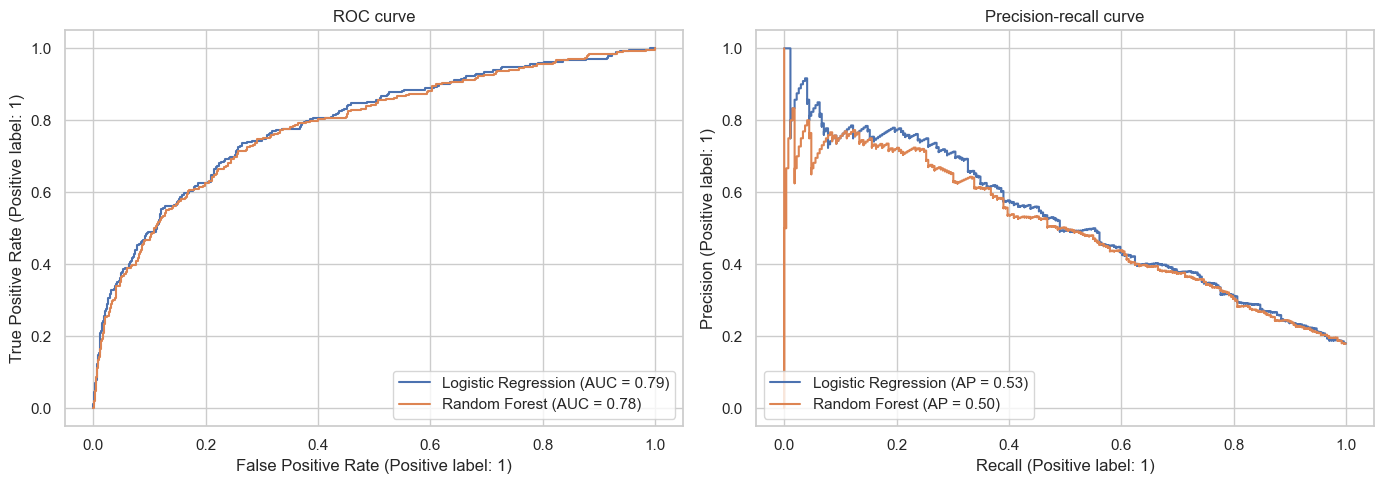

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model in model_run.models.items():
    probability = model.predict_proba(model_run.x_test)[:, 1]
    RocCurveDisplay.from_predictions(model_run.y_test, probability, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(model_run.y_test, probability, name=name, ax=axes[1])

axes[0].set_title("ROC curve")
axes[1].set_title("Precision-recall curve")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_roc_pr_curves.png", dpi=180, bbox_inches="tight")
plt.show()


Classification report at 0.50 threshold


,precision,recall,f1-score,support
0,0.925,0.742,0.824,"1,231.000"
1,0.381,0.725,0.499,269.000
accuracy,0.739,0.739,0.739,0.739
macro avg,0.653,0.734,0.662,"1,500.000"
weighted avg,0.828,0.739,0.766,"1,500.000"


Confusion matrix at 0.50 threshold
[[914 317]
 [ 74 195]]


,Feature,AbsoluteCoefficient
0,ChronicCount,0.421
1,PaidClaimsPMPM,0.375
2,CareGapCount,0.327
3,New_Diagnosis_Flag,0.295
4,Prior_HCC_Flag,0.240
5,ProviderGroup_Golden Valley,0.233
6,ProviderGroup_Harbor Physicians,0.187
7,ProviderGroup_Frontier Health,0.180
8,Age,0.131
9,ProviderGroup_Alpha Medical Group,0.131


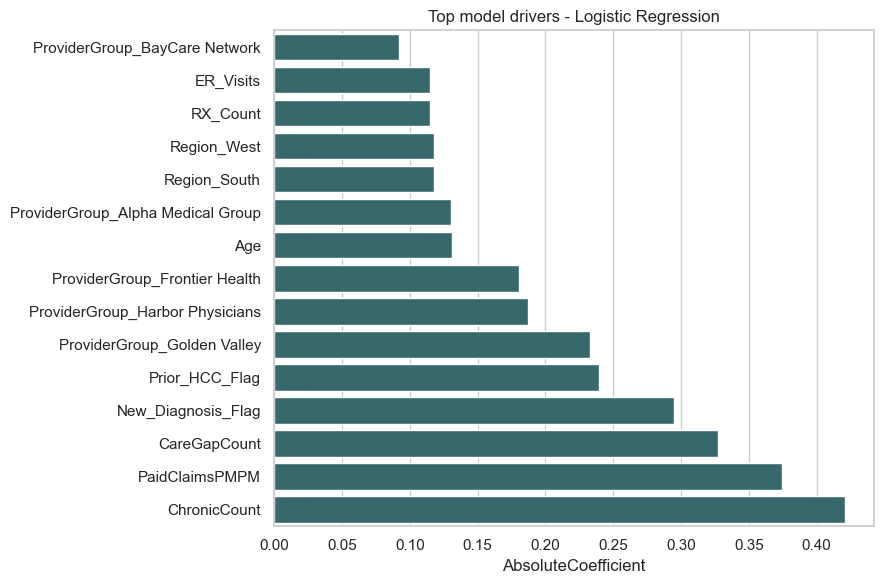

In [8]:
class_report, confusion = classification_summary(best_model, model_run.x_test, model_run.y_test)
print("Classification report at 0.50 threshold")
display(class_report.round(3))

print("Confusion matrix at 0.50 threshold")
print(confusion)

importance = feature_importance(best_model, top_n=15)
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
display(importance)

importance_col = [col for col in importance.columns if col != "Feature"][0]
plt.figure(figsize=(9, 6))
sns.barplot(data=importance.sort_values(importance_col), x=importance_col, y="Feature", color="#2f6f73")
plt.title(f"Top model drivers - {best_model_name}")
plt.xlabel(importance_col)
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## 7️⃣ Operational Priority Queue

### From model score to business workflow

This is the most important part of the project.

A model probability alone is not enough. Healthcare teams need a usable worklist.

The project converts model probabilities into:

- `RiskRank`
- `PriorityTier`
- `EstimatedOpportunityPMPM`
- provider action summaries
- top-member review queues

### Priority tiers

- Critical: review first
- High: strong follow-up candidate
- Medium: queue after top tiers
- Monitor: keep in monthly refresh


In [9]:
scored_members = score_members(df, best_model)
priority_summary = summarize_priority_queue(scored_members)
provider_table = provider_action_table(scored_members)

top_members = scored_members[
    [
        "MemberID",
        "ProviderGroup",
        "Region",
        "PlanID",
        "Age",
        "ChronicCount",
        "RAF_Score",
        "PaidClaimsPMPM",
        "CareGapCount",
        "SuspectProbability",
        "PriorityTier",
        "EstimatedOpportunityPMPM",
    ]
].head(25)

scored_members.to_csv(OUTPUT_DIR / "scored_member_priority_queue.csv", index=False)
priority_summary.to_csv(OUTPUT_DIR / "priority_tier_summary.csv", index=False)
provider_table.to_csv(OUTPUT_DIR / "provider_action_table.csv", index=False)
top_members.to_csv(OUTPUT_DIR / "top_25_member_opportunities.csv", index=False)

display(priority_summary.round(3))
display(provider_table.head(10).round(3))
display(top_members.round(3))


,PriorityTier,Members,SuspectRate,AvgProbability,AvgRAF,AvgClaimsPMPM,EstOpportunityPMPM
0,Monitor,3500,0.094,0.315,0.513,645.720,15.119
1,Medium,1000,0.276,0.637,0.864,"1,072.487",49.870
2,High,350,0.514,0.827,1.126,"1,481.248",83.534
3,Critical,150,0.747,0.936,1.379,"2,067.672",114.833


,ProviderGroup,Members,SuspectRate,AvgRAF,AvgClaimsPMPM,CriticalMembers,EstOpportunityPMPM
0,Harbor Physicians,590,0.207,0.674,864.859,30,33.238
1,Frontier Health,695,0.174,0.643,819.048,27,31.247
2,BayCare Network,558,0.197,0.672,835.857,19,31.657
3,Cedar Health,593,0.191,0.654,844.446,18,30.733
4,Golden Valley,612,0.150,0.628,830.766,17,25.848
5,Delta IPA,619,0.189,0.652,829.820,16,29.809
6,Alpha Medical Group,700,0.154,0.628,797.730,12,26.963
7,Evergreen Clinic,633,0.179,0.670,843.485,11,29.838


,MemberID,ProviderGroup,Region,PlanID,Age,ChronicCount,RAF_Score,PaidClaimsPMPM,CareGapCount,SuspectProbability,PriorityTier,EstimatedOpportunityPMPM
0,103224,Cedar Health,West,PlanA_Silver,84,4,2.460,"4,143.760",2,0.994,Critical,213.890
1,100213,Harbor Physicians,South,PlanA_Silver,58,3,1.515,"4,424.550",1,0.992,Critical,131.520
2,103710,Frontier Health,Northeast,PlanA_Silver,60,4,2.059,"1,660.700",3,0.990,Critical,178.300
3,100408,BayCare Network,West,PlanA_Silver,57,3,1.641,"1,729.460",6,0.989,Critical,142.070
4,102895,Frontier Health,West,PlanB_Gold,77,3,1.789,"2,194.030",4,0.988,Critical,176.680
5,102970,Frontier Health,Midwest,PlanB_Gold,68,3,1.574,"2,719.610",3,0.987,Critical,155.410
6,100263,Harbor Physicians,West,PlanC_Bronze,72,4,1.981,"2,432.320",1,0.984,Critical,146.150
7,102003,Evergreen Clinic,South,PlanA_Silver,56,3,1.585,"2,481.870",2,0.983,Critical,136.360
8,100041,BayCare Network,Northeast,PlanA_Silver,37,3,1.584,"2,590.470",2,0.982,Critical,136.170
9,102987,Harbor Physicians,South,PlanA_Silver,56,2,0.979,"2,761.690",3,0.982,Critical,84.150


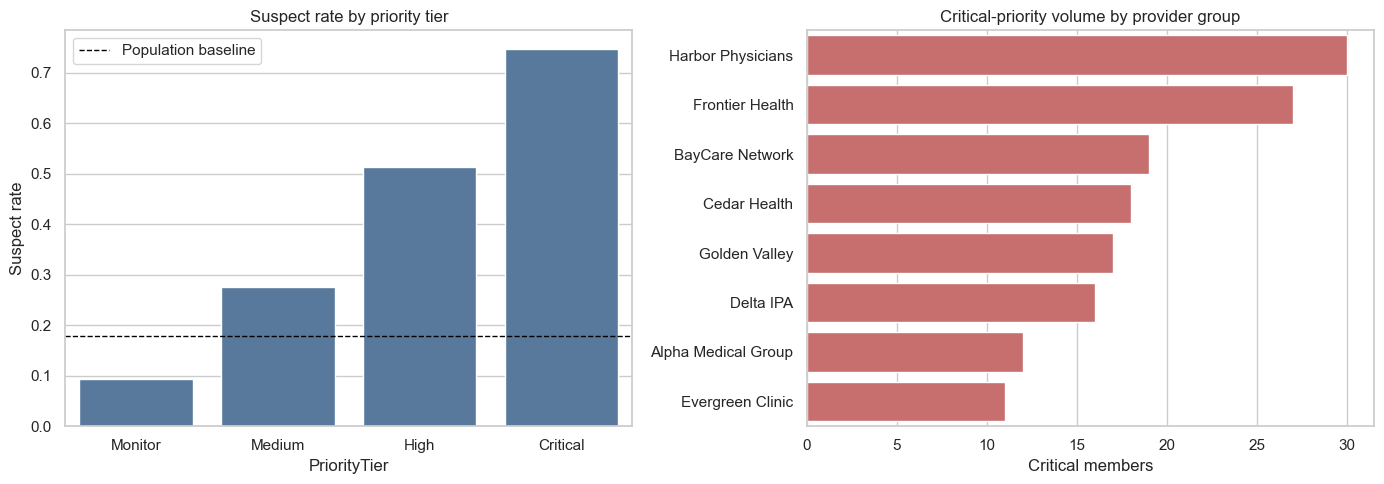

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=priority_summary, x="PriorityTier", y="SuspectRate", ax=axes[0], color="#4c78a8")
axes[0].axhline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1, label="Population baseline")
axes[0].set_title("Suspect rate by priority tier")
axes[0].set_ylabel("Suspect rate")
axes[0].legend()

sns.barplot(
    data=provider_table.head(8),
    y="ProviderGroup",
    x="CriticalMembers",
    ax=axes[1],
    color="#d65f5f",
)
axes[1].set_title("Critical-priority volume by provider group")
axes[1].set_xlabel("Critical members")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "priority_queue_summary.png", dpi=180, bbox_inches="tight")
plt.show()


## 8️⃣ Statistical Validation and Adjustment Checks

### Why add statistics?

Machine learning gives prediction power, but healthcare analytics also needs statistical reasoning.

This section adds:

- t-test for regional RAF differences
- chi-square test for gender vs suspect flag
- OLS regression to understand adjusted RAF drivers

### Interview checkpoint

This shows that the project is not just dashboarding. It includes statistical validation and interpretable risk adjustment thinking.


In [11]:
west = df.loc[df["Region"] == "West", "RAF_Score"]
south = df.loc[df["Region"] == "South", "RAF_Score"]
t_stat, p_value = stats.ttest_ind(west, south, equal_var=False)
print(f"Welch t-test: West vs South RAF score -> t={t_stat:.3f}, p={p_value:.4f}")

contingency = pd.crosstab(df["Gender"], df[TARGET])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: Gender vs suspect flag -> chi2={chi2:.3f}, p={chi_p:.4f}, dof={dof}")
display(contingency)

adjustment_features = ["Age", "ChronicCount", "Prior_HCC_Flag", "New_Diagnosis_Flag", "ER_Visits", "Inpatient_Admits"]
x_adj = sm.add_constant(df[adjustment_features])
ols = sm.OLS(df["RAF_Score"], x_adj).fit()
adjusted_summary = pd.DataFrame(
    {
        "Coefficient": ols.params,
        "PValue": ols.pvalues,
    }
).round(4)

display(adjusted_summary)
print(f"Adjusted RAF model R-squared: {ols.rsquared:.3f}")


Welch t-test: West vs South RAF score -> t=0.011, p=0.9916
Chi-square: Gender vs suspect flag -> chi2=0.717, p=0.3970, dof=1


SuspectFlag,0,1
Gender,,
F,2118,477
M,1986,419


,Coefficient,PValue
const,0.048,0.000
Age,0.006,0.000
ChronicCount,0.406,0.000
Prior_HCC_Flag,0.229,0.000
New_Diagnosis_Flag,0.002,0.813
ER_Visits,0.003,0.610
Inpatient_Admits,0.015,0.035


Adjusted RAF model R-squared: 0.795


## 9️⃣ Plan-Level Risk Transfer Illustration

### Business interpretation

Risk adjustment is not only clinical or operational. It can also affect plan-level financial exposure.

This section creates a simplified plan-level transfer table using:

- RAF score
- actuarial value
- member months
- premium assumption

This is not a regulatory payment model. It is an illustrative finance layer for portfolio storytelling.


,PlanID,WeightedRisk,PLRS,TotalMemberMonths,TransferPMPM,TransferDirection
0,PlanB_Gold,0.672,0.537,15222,32.107,Receivable
1,PlanA_Silver,0.647,0.453,20007,-5.974,Payable
2,PlanC_Bronze,0.631,0.378,9354,-39.469,Payable


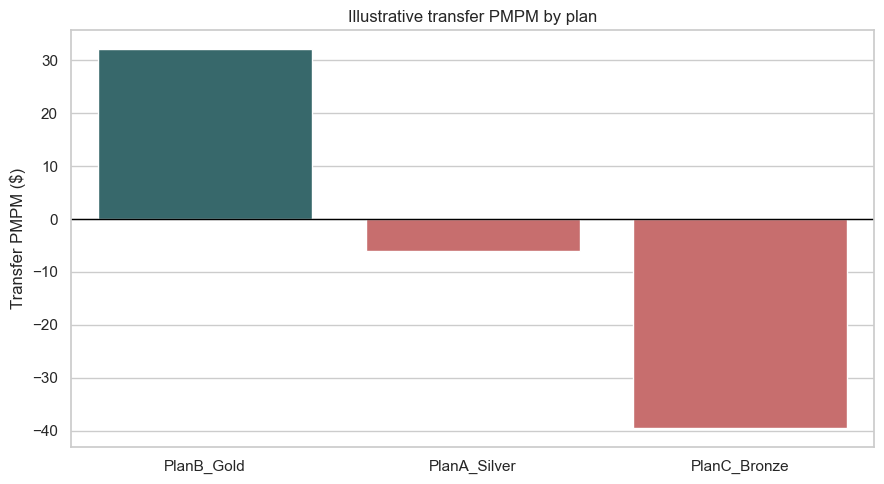

In [12]:
transfer_table = plan_transfer_table(df, premium_pmpm=450)
transfer_table.to_csv(OUTPUT_DIR / "plan_risk_transfer_summary.csv", index=False)
display(transfer_table.round(3))

plt.figure(figsize=(9, 5))
colors = transfer_table["TransferPMPM"].map(lambda value: "#2f6f73" if value > 0 else "#d65f5f")
sns.barplot(data=transfer_table, x="PlanID", y="TransferPMPM", palette=list(colors))
plt.axhline(0, color="black", linewidth=1)
plt.title("Illustrative transfer PMPM by plan")
plt.xlabel("")
plt.ylabel("Transfer PMPM ($)")
plt.tight_layout()
plt.savefig(FIG_DIR / "plan_risk_transfer.png", dpi=180, bbox_inches="tight")
plt.show()


## 🔟 Final Output Checklist

By the end of this notebook, the project produces:

- synthetic healthcare member dataset
- model metrics
- feature importance table
- scored member priority queue
- provider action table
- top 25 member opportunities
- priority-tier summary
- plan risk-transfer summary
- saved figures for README and reporting


In [13]:
expected_outputs = [
    DATA_DIR / "synthetic_healthcare_risk_members.csv",
    OUTPUT_DIR / "model_metrics.csv",
    OUTPUT_DIR / "feature_importance.csv",
    OUTPUT_DIR / "priority_tier_summary.csv",
    OUTPUT_DIR / "provider_action_table.csv",
    OUTPUT_DIR / "scored_member_priority_queue.csv",
    OUTPUT_DIR / "top_25_member_opportunities.csv",
    OUTPUT_DIR / "plan_risk_transfer_summary.csv",
    FIG_DIR / "eda_healthcare_risk_signals.png",
    FIG_DIR / "model_roc_pr_curves.png",
    FIG_DIR / "feature_importance.png",
    FIG_DIR / "priority_queue_summary.png",
    FIG_DIR / "plan_risk_transfer.png",
]

output_check = pd.DataFrame(
    {
        "Artifact": [path.name for path in expected_outputs],
        "Exists": [path.exists() for path in expected_outputs],
        "Path": [str(path.relative_to(PROJECT_ROOT)) for path in expected_outputs],
    }
)

display(output_check)


,Artifact,Exists,Path
0,synthetic_healthcare_risk_members.csv,True,data/synthetic_healthcare_risk_members.csv
1,model_metrics.csv,True,outputs/model_metrics.csv
2,feature_importance.csv,True,outputs/feature_importance.csv
3,priority_tier_summary.csv,True,outputs/priority_tier_summary.csv
4,provider_action_table.csv,True,outputs/provider_action_table.csv
5,scored_member_priority_queue.csv,True,outputs/scored_member_priority_queue.csv
6,top_25_member_opportunities.csv,True,outputs/top_25_member_opportunities.csv
7,plan_risk_transfer_summary.csv,True,outputs/plan_risk_transfer_summary.csv
8,eda_healthcare_risk_signals.png,True,outputs/figures/eda_healthcare_risk_signals.png
9,model_roc_pr_curves.png,True,outputs/figures/model_roc_pr_curves.png


## 🗣️ Data Science Interview Explanation

### 30-second pitch

I built a healthcare risk adjustment analytics project that simulates payer member data, predicts suspect documentation opportunities, and converts model probabilities into an operational review queue. The final output is a Streamlit app that helps healthcare teams filter members, simulate review capacity, inspect provider groups, estimate financial value, and download prioritized worklists.

### 2-minute technical explanation

1. I generated a synthetic HIPAA-safe member dataset with demographics, utilization, chronic conditions, RAF score, claims PMPM, plan attributes, and care gaps.
2. I performed EDA to validate healthcare risk patterns such as chronic burden, RAF score distribution, claims PMPM, and provider-level suspect variation.
3. I trained Logistic Regression and Random Forest models to predict `SuspectFlag`.
4. I evaluated the models using ROC AUC, average precision, recall, F1, top-decile lift, and top-decile capture.
5. I selected the best model and converted probabilities into priority tiers.
6. I created provider action tables and plan-level transfer summaries.
7. I deployed the workflow into a Streamlit dashboard for interactive decision support.

### Why this project matters

This project shows that I can connect machine learning to a real healthcare business process. The key is not only prediction. The key is turning prediction into action.


## ❓ Interview Questions I Should Be Ready For

### Why did you use Logistic Regression if Random Forest is more flexible?

Because Logistic Regression performed slightly better in this synthetic setup and is easier to explain to healthcare stakeholders. Explainability matters in healthcare analytics.

### Why use top-decile lift?

Because the business problem is capacity-limited. If the team can only review a small portion of members, the highest-ranked members need to be much better than random selection.

### What would you improve with real data?

I would add claim lines, diagnosis history, encounter timing, provider coding patterns, calibration, subgroup fairness checks, temporal validation, and feedback from actual chart review outcomes.

### How would you productionize this?

I would schedule monthly scoring, monitor drift, store review outcomes, retrain on validated feedback, add model governance documentation, and integrate the output with an operational work queue.


## ⭐ Final Takeaway

This notebook is meant to be readable, explainable, and interview-ready.

The main project story is:

> I used healthcare domain logic, predictive modeling, ranking metrics, and Streamlit product design to turn synthetic payer data into a practical risk adjustment decision-support workflow.

That is the bigger picture.
